# Study v2: damage and participant harm

The unit is one driver in one incident. A multi-car collision therefore has a separate record for
each participant. Timing decides what to research; it does not prove damage.

In [1]:
# ruff: noqa: E402
import json
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REVIEW = ROOT / "data/manual/study_v2_review_packets/study-v2-review-7cb1b29b5251"
REFERRAL = ROOT / "data/manual/study_v2_referrals/referrals-5d0559ad2878"
CLOCK = ROOT / "data/manual/study_v2_incident_clock/incident-clock-3dc8bb350308"
CONTEXT = ROOT / "data/manual/study_v2_incident_context/incident-context-a1de9ac2c8ea"
CLOSE = ROOT / "data/manual/study_v2_close_cases/close-cases-36f9bc70de82"
DAMAGE = ROOT / "data/manual/study_v2_damage/damage-screening-66381b550583"
LAYERS = ROOT / "data/manual/study_v2_layers/study-v2-layers-a9b8ff776470"
NATIONALITY = ROOT / "data/manual/study_v2_nationality/nationality-diagnostic-2b1b0ffdd961"
GENERATED = ROOT / "reports/generated/study_v2"
GENERATED.mkdir(parents=True, exist_ok=True)

In [2]:
damage_manifest = json.loads((DAMAGE / "manifest.json").read_text(encoding="utf-8"))
layer_manifest = json.loads((LAYERS / "manifest.json").read_text(encoding="utf-8"))
screen = pd.read_csv(DAMAGE / "harm_screening.csv")
pace = pd.read_csv(LAYERS / "persistent_pace_screen.csv")
evidence = pd.read_csv(DAMAGE / "damage_evidence_review_worklist.csv")
summary = pd.DataFrame([{
    "collision decision rows": damage_manifest["collision_decision_rows"],
    "candidate incidents": damage_manifest["candidate_incident_count"],
    "participant records": len(screen),
    "single-lap participant mappings": damage_manifest["participant_rows_with_incident_lap"],
    "pace candidates": len(pace),
    "estimable teammate-relative screens": layer_manifest["pace_screen_estimable_rows"],
    "model-researched sources awaiting review": len(evidence),
    "reviewed proportionality records": layer_manifest["proportionality_release_rows"],
}])
display(summary.T.rename(columns={0: "count"}))
display(evidence[["event_id", "participant_driver_number", "source_owner", "source_grade", "source_url", "independent_review_status"]])

,count
collision decision rows,233
candidate incidents,193
participant records,411
single-lap participant mappings,240
pace candidates,52
estimable teammate-relative screens,28
model-researched sources awaiting review,4
reviewed proportionality records,0


,event_id,participant_driver_number,source_owner,source_grade,source_url,independent_review_status
0,2019-bhr,55,Formula 1,A3,https://www.formula1.com/en/latest/article/sai...,pending
1,2023-jpn,77,Formula 1,A3,https://www.formula1.com/en/latest/article/bot...,pending
2,2023-jpn,2,Williams Racing,A2,https://www.williamsf1.com/posts/05f49fb5-62ac...,pending
3,2024-mia,81,Formula 1,A3,https://www.formula1.com/en/latest/article/sai...,pending


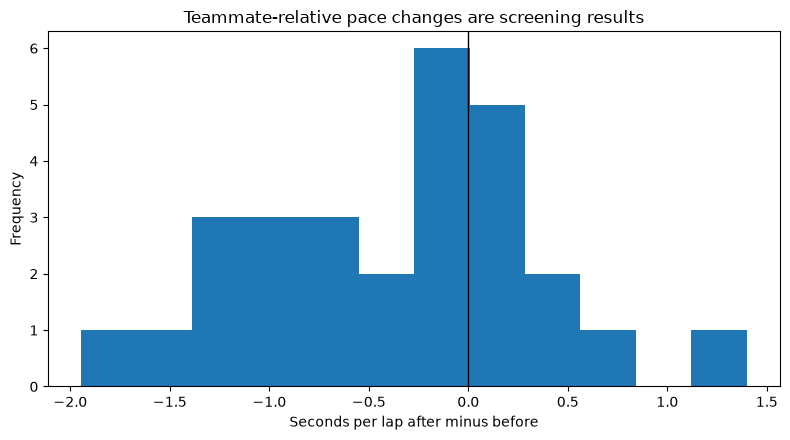

In [3]:
estimated = pace.loc[pace["pace_screen_status"].str.startswith("estimable")].copy()
ax = estimated["pace_change_seconds_per_lap"].plot.hist(bins=12, figsize=(8, 4.5))
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Teammate-relative pace changes are screening results", xlabel="Seconds per lap after minus before")
plt.tight_layout()
plt.savefig(GENERATED / "pace_screen_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

Only 28 of 52 pace candidates have enough clean laps matched on the same lap to a teammate. Traffic,
tyres, strategy, weather, and hidden damage can still explain those changes. The four researched
source examples remain pending human confirmation. No population damage rate or proportionality
claim is released.